In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from tqdm import tqdm
from typing import List, Tuple, Optional

import matplotlib.pyplot as plt
from PIL import Image

In [2]:
from src.gradcam import GradCAM
from src.activation import ActivationMapCollector
from src.model import FineTunedModel


In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ----------------------------------------------------
# 1. ĐỊNH NGHĨA ĐƯỜNG DẪN VÀ BATCH SIZE
# ----------------------------------------------------
# Lấy đường dẫn từ ảnh của bạn
data_dir = 'data/imagenette' 
BATCH_SIZE = 1

# ----------------------------------------------------
# 2. ĐỊNH NGHĨA CÁC PHÉP BIẾN ĐỔI (TRANSFORMS)
# ----------------------------------------------------
# Đây là bước rất quan trọng.
# Model của bạn (giống AlexNet) cần ảnh đầu vào có kích thước
# cố định (ví dụ: 224x224) và đã được chuẩn hóa.

data_transform = transforms.Compose([
    # Resize ảnh về kích thước 224x224
    transforms.Resize((224, 224)),
    
    # (Tùy chọn) Thêm Augmentation để model học tốt hơn
    # transforms.RandomHorizontalFlip(), # Lật ảnh ngẫu nhiên
    
    # Chuyển ảnh (PIL Image) sang Tensor (PyTorch)
    # và scale giá trị pixel từ [0, 255] về [0.0, 1.0]
    transforms.ToTensor(),
    
    # Chuẩn hóa ảnh với Mean và Std của ImageNet
    # (Rất quan trọng nếu bạn dùng pre-trained weights)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ----------------------------------------------------
# 3. TẠO DATASET BẰNG IMAGEFOLDER
# ----------------------------------------------------
# Đây là "phép thuật" - nó tự động tìm các lớp
# từ tên thư mục con.
full_dataset = datasets.ImageFolder(
    root=data_dir,
    transform=data_transform
)

print(f"Tìm thấy {len(full_dataset)} ảnh trong {len(full_dataset.classes)} lớp.")
print("Các lớp được tìm thấy:", full_dataset.classes)

# ----------------------------------------------------
# 4. TẠO DATALOADER
# ----------------------------------------------------
# DataLoader chịu trách nhiệm xáo trộn (shuffle),
# tạo batch, và tải dữ liệu song song.

data_loader = DataLoader(
    full_dataset,
    batch_size=BATCH_SIZE,

)

# ----------------------------------------------------
# 5. (TÙY CHỌN) KIỂM TRA
# ----------------------------------------------------
print("\nKiểm tra một batch từ DataLoader:")
try:
    # Lấy một batch đầu tiên
    images, labels = next(iter(data_loader))
    
    print(f"- Kích thước batch ảnh (Images shape): {images.shape}") 
    # Sẽ in ra: [64, 3, 224, 224] (Batch, Channels, Height, Width)
    
    print(f"- Kích thước batch nhãn (Labels shape): {labels.shape}") 
    # Sẽ in ra: [64]
    
except Exception as e:
    print(f"Lỗi khi tải dữ liệu: {e}")

Tìm thấy 13394 ảnh trong 10 lớp.
Các lớp được tìm thấy: ['English_springer', 'French_horn', 'cassette_player', 'chain_saw', 'church', 'garbage_truck', 'gas_pump', 'golf_ball', 'parachute', 'tench']

Kiểm tra một batch từ DataLoader:
- Kích thước batch ảnh (Images shape): torch.Size([1, 3, 224, 224])
- Kích thước batch nhãn (Labels shape): torch.Size([1])


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FineTunedModel(num_classes=10).to(device)
model.load_state_dict(torch.load('weights/finetune_weights.pth'))
target_layer = model.feature_extractor[5]


In [5]:
print(model)

FineTunedModel(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(6, 6))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dropout(p=0.5, inplace=False)
    (3): Li

In [6]:
collector = ActivationMapCollector(model, target_layer, device=device)
maps = collector.collect_maps(data_loader, output_tensor=True, device=device)


  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [9]:
len(maps)

833019

In [10]:
import importlib
import src.batch_cdl
importlib.reload(src.batch_cdl)
from src.batch_cdl import roto_cdl_batch_train

In [9]:
import importlib
import src.batch_cdl_large
importlib.reload(src.batch_cdl_large)
from src.batch_cdl_large import roto_cdl_large_scale

In [ ]:
phi = roto_cdl_large_scale(
    maps,
    n_atoms=50,  # Set to 500 for real run
    batch_size=1024,
    n_epochs=5,
    device=device
)

In [12]:
# 1. Train Dictionary
phi_learned = roto_cdl_batch_train(maps, n_atoms=100, batch_size=500, n_epochs=40, device=device)


Starting Batch Training on 833019 images...


KeyboardInterrupt: 

In [ ]:
import importlib
import src.hals_nnd
importlib.reload(src.hals_nnd)

from src.hals_nnd import hals_nnd_correct
D, W, loss_history = hals_nnd_correct(
    maps, m=500, nsteps=20, batch_size=2000, device=device
)

HALS v2.1
Starting HALS-NND optimization: v0
  Data: 833019 samples of size 13x13
  Dictionary: 500 atoms
  Epochs: 20, Batch size: 2000
  λ_D=0.001, λ_W=0.05, γ=0.001, η=0.01


Training:   5%|▌         | 1/20 [00:14<04:30, 14.24s/it, loss=956.827611, recon=925.755178, reg=31.072433, Δ=0.00e+00, status=✓ new best]

[epoch 0] ||W||_F=22738.104, ||grad_D||_F=249.820


Training:  10%|█         | 2/20 [00:27<04:02, 13.48s/it, loss=651.168330, recon=626.456979, reg=24.711352, Δ=-3.06e+02, status=✓ new best]

[epoch 1] ||W||_F=20273.311, ||grad_D||_F=102.517


...

[epoch 17] ||W||_F=20821.770, ||grad_D||_F=39.353


Training:  95%|█████████▌| 19/20 [03:55<00:12, 12.16s/it, loss=340.429592, recon=314.097814, reg=26.331778, Δ=-5.95e+00, status=✓ new best]

[epoch 18] ||W||_F=20931.555, ||grad_D||_F=39.193


Training: 100%|██████████| 20/20 [04:05<00:00, 12.28s/it, loss=334.694338, recon=308.087425, reg=26.606913, Δ=-5.74e+00, status=✓ new best]

[epoch 19] ||W||_F=21041.145, ||grad_D||_F=39.044

Optimization completed:
  Final total loss:  334.694338
  Final recon loss:  308.087425
  Final reg loss:    26.606913
  Best total loss:   334.694338
  W sparsity:        8.0% non-zero
  D sparsity:        40.9% non-zero


In [ ]:
loss_history.keys()

dict_keys(['total', 'reconstruction', 'regularization'])

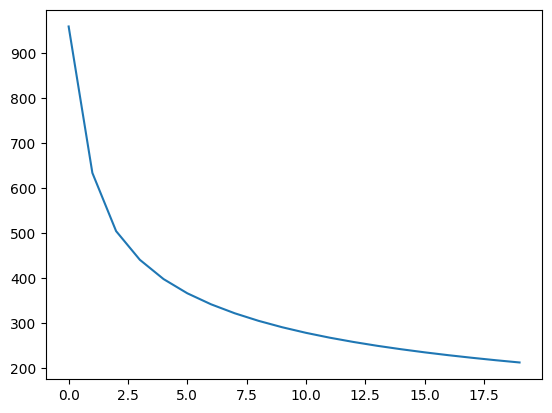

In [ ]:
plt.plot(loss_history['total'][:])

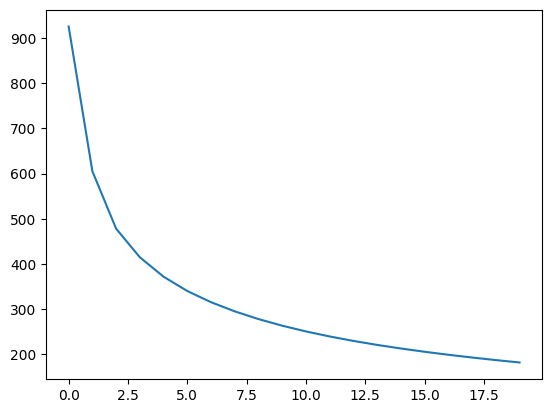

In [ ]:
plt.plot(loss_history['reconstruction'][:])

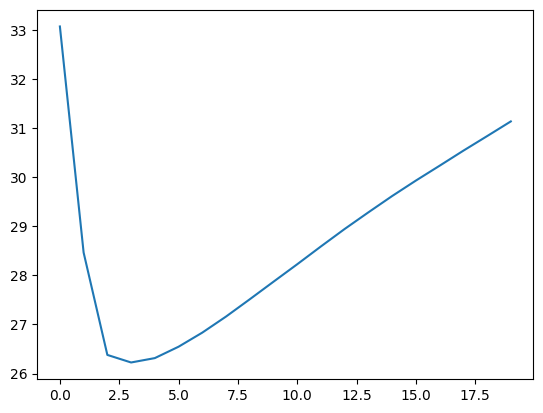

In [ ]:
plt.plot(loss_history['regularization'][:])

In [ ]:
torch.save(D, 'weights/hals_nnd_D.pth')

In [ ]:
import torch
import matplotlib.pyplot as plt
import math

def compute_atom_usage(W):
    return W.sum(dim=0)

def top_k_atoms_by_usage(W, K=12):
    usage = W.sum(dim=0)
    vals, idxs = torch.topk(usage, K, largest=True)
    return idxs.cpu(), vals.cpu()

def visualize_top_atoms(D, W, K=12, cmap='viridis'):
    D = D.detach().cpu()
    W = W.detach().cpu()

    usage = W.sum(dim=0)
    vals, idxs = torch.topk(usage, K, largest=True)

    cols = int(math.sqrt(K))
    rows = math.ceil(K / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(2.5*cols, 2.5*rows))

    for i in range(rows * cols):
        ax = axes[i // cols, i % cols]
        ax.axis("off")
        if i < K:
            k = idxs[i].item()
            ax.imshow(D[k], cmap=cmap)
            ax.set_title(f"D[{k}]  (usage={vals[i]:.2f})", fontsize=6)

    plt.tight_layout()
    plt.show()

# Example usage:
# visualize_top_atoms(best_D, best_W, K=12, cmap='gray')


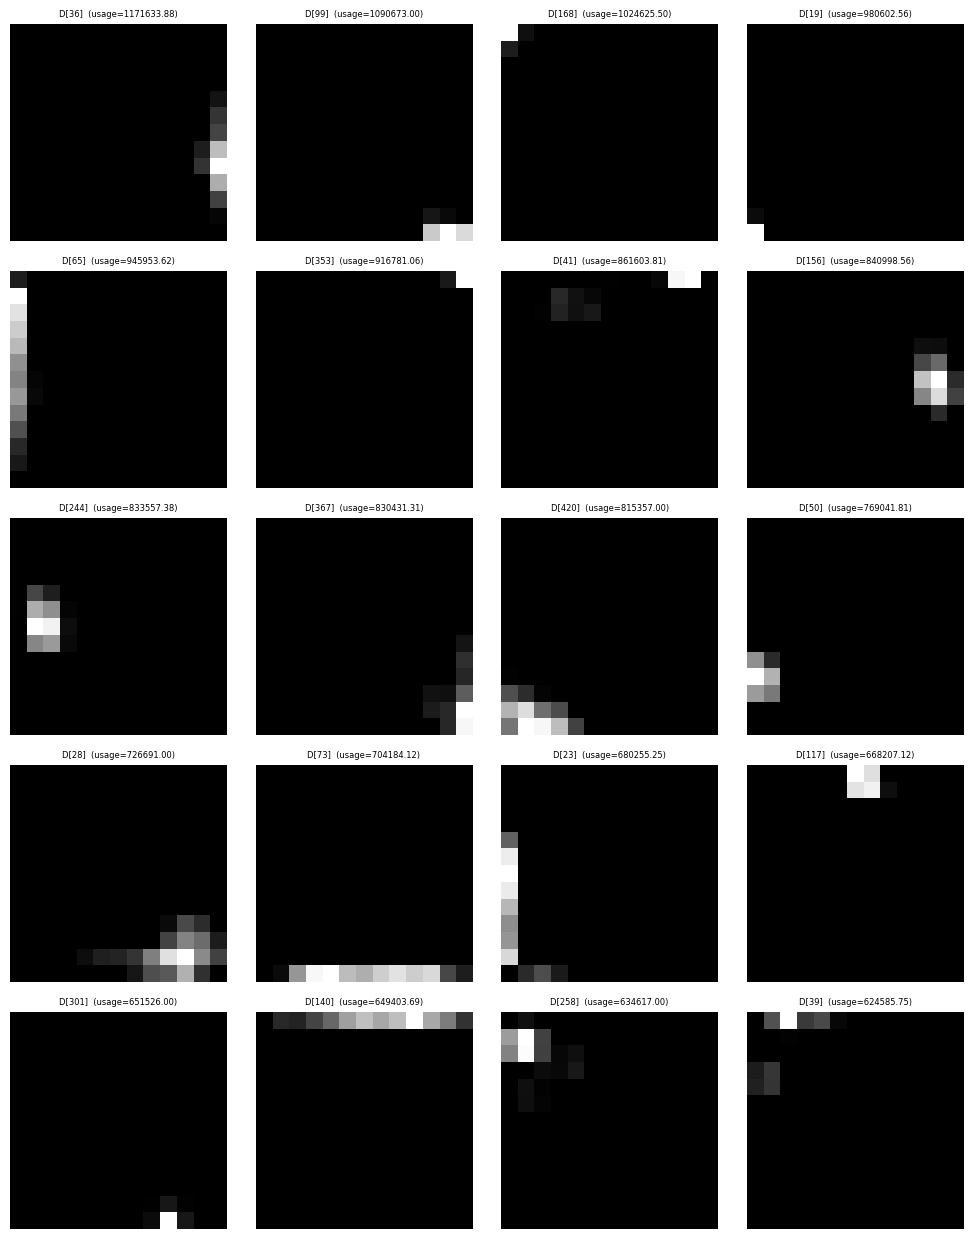

In [ ]:
visualize_top_atoms(D, W, K=20, cmap='gray')